# **MidSem Lab Exam**

## Q1. Implement a Feed Forward Neural Network (FNN) using Diabetes Dataset.

In [109]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader, TensorDataset, Subset
import matplotlib.pyplot as plt

In [110]:
df= pd.read_csv("diabetes.csv")

X = df.iloc[:, :-1].values
y =df.iloc[:, -1].values.reshape(-1,1)

scaler = StandardScaler()
X=scaler.fit_transform(X)

X_train,X_temp, y_train, y_temp = train_test_split(X, y,test_size=0.3, random_state=42, stratify = y)
X_val, X_test,y_val, y_test = train_test_split(X_temp,y_temp, test_size=0.5,random_state=42, stratify = y_temp) 

In [111]:
train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
val_ds = TensorDataset(torch.tensor(X_val, dtype=torch.float32),torch.tensor(y_val, dtype=torch.float32))
test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32),torch.tensor(y_test, dtype=torch.float32))

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16)
test_loader = DataLoader(test_ds, batch_size=16)

In [112]:
class FNN(nn.Module):
    def __init__(self, input_dim, dropout_rate):
        super(FNN,self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [113]:
def plot_curve(train, val, ylabel, title):
    plt.figure()
    plt.plot(train, label="Train")
    plt.plot(val, label="Validation")
    plt.xlabel("Epochs")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [114]:
def train_model(model, train_load, val_load, criterion, optimizer, epochs):
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    correct = 0
    total = 0
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_load:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            predicted = (outputs>=0.5).float()
            correct += (predicted == y_batch).sum().item()
            total+=y_batch.size(0)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_acc = correct/total
        train_accs.append(train_acc)
        train_loss /= len(train_load)
        train_losses.append(train_loss)
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_load:
                outputs = model(X_batch)
                predicted = (outputs>=0.5).float()
                correct += (predicted == y_batch).sum().item()
                total+=y_batch.size(0)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
            val_acc = correct/total
            val_accs.append(val_acc)
            val_loss /= len(val_load)
            val_losses.append(val_loss)
        print(f"Epoch {epoch+1}/{epochs}, Train_Loss: {train_loss:.4f}, val_Loss: {val_loss:.4f}")
    return train_losses, val_losses, train_accs, val_accs

In [115]:
configs = [
    {"optimizer": "Adam", "lr": 0.01, "dropout": 0.2, "batch_size": 16, "Epochs": 100},
    {"optimizer": "SGD", "lr": 0.001, "dropout": 0.3, "batch_size": 16, "Epochs": 50}
]

In [116]:
history = []
test_accs = []

for config in configs:
    model = FNN(X_train.shape[1], config["dropout"])
    criterion = nn.BCELoss()
    if config["optimizer"] == "Adam":
        optimizer = optim.Adam(model.parameters(), lr = config['lr'])
    elif config["optimizer"] == "SGD":
        optimizer = optim.SGD(model.parameters(), lr = config['lr'], momentum = 0.9)
    
    print("Configuration is: ", config)
    print()
    history.append(train_model(model, train_loader, val_loader, criterion, optimizer, config["Epochs"]))
    print()
    print()
    model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for X_batch, y_batch in test_loader:
            y_pred = model(X_batch)
            predicted = (y_pred>=0.5).float()
            correct += (predicted == y_batch).sum().item()
            total+=y_batch.size(0)
        test_acc = correct/total
    test_accs.append(test_acc)    

Configuration is:  {'optimizer': 'Adam', 'lr': 0.01, 'dropout': 0.2, 'batch_size': 16, 'Epochs': 100}

Epoch 1/100, Train_Loss: 0.5610, val_Loss: 0.5157
Epoch 2/100, Train_Loss: 0.4818, val_Loss: 0.5096
Epoch 3/100, Train_Loss: 0.4834, val_Loss: 0.4685
Epoch 4/100, Train_Loss: 0.4629, val_Loss: 0.4970
Epoch 5/100, Train_Loss: 0.4441, val_Loss: 0.5023
Epoch 6/100, Train_Loss: 0.4582, val_Loss: 0.5102
Epoch 7/100, Train_Loss: 0.4296, val_Loss: 0.5684
Epoch 8/100, Train_Loss: 0.4356, val_Loss: 0.5256
Epoch 9/100, Train_Loss: 0.4190, val_Loss: 0.5377
Epoch 10/100, Train_Loss: 0.4214, val_Loss: 0.6228
Epoch 11/100, Train_Loss: 0.4350, val_Loss: 0.5503
Epoch 12/100, Train_Loss: 0.4199, val_Loss: 0.5406
Epoch 13/100, Train_Loss: 0.3920, val_Loss: 0.5511
Epoch 14/100, Train_Loss: 0.4120, val_Loss: 0.6012
Epoch 15/100, Train_Loss: 0.4028, val_Loss: 0.6477
Epoch 16/100, Train_Loss: 0.3923, val_Loss: 0.5987
Epoch 17/100, Train_Loss: 0.3877, val_Loss: 0.6185
Epoch 18/100, Train_Loss: 0.3753, val_L

In [117]:
print("Test Accuracy of First Config: ", test_accs[0])
print("Test Accuracy of Second Config: ", test_accs[1])

Test Accuracy of First Config:  0.6982758620689655
Test Accuracy of Second Config:  0.7327586206896551


In [118]:
class FNNmod(nn.Module):
    def __init__(self, input_dim, dropout_rate):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [129]:
history_mod = []
test_accs = []

for config in configs:
    model_mod = FNNmod(X_train.shape[1], config["dropout"])
    criterion = nn.BCELoss()
    if config["optimizer"] == "Adam":
        optimizer = optim.Adam(model_mod.parameters(), lr = config['lr'])
    elif config["optimizer"] == "SGD":
        optimizer = optim.SGD(model_mod.parameters(), lr = config['lr'], momentum = 0.9)

    print("Configuration is: ", config)
    print()
    history_mod.append(train_model(model_mod, train_loader, val_loader, criterion, optimizer, config["Epochs"]))
    print()
    print()

    model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for X_batch, y_batch in test_loader:
            y_pred = model_mod(X_batch)
            predicted = (y_pred>=0.5).float()
            correct += (predicted == y_batch).sum().item()
            total+=y_batch.size(0)
        test_acc = correct/total
    test_accs.append(test_acc)

Configuration is:  {'optimizer': 'Adam', 'lr': 0.01, 'dropout': 0.2, 'batch_size': 16, 'Epochs': 100}

Epoch 1/100, Train_Loss: 0.5753, val_Loss: 0.4709
Epoch 2/100, Train_Loss: 0.4860, val_Loss: 0.4791
Epoch 3/100, Train_Loss: 0.4500, val_Loss: 0.4821
Epoch 4/100, Train_Loss: 0.4915, val_Loss: 0.4889
Epoch 5/100, Train_Loss: 0.4567, val_Loss: 0.5134
Epoch 6/100, Train_Loss: 0.4316, val_Loss: 0.4871
Epoch 7/100, Train_Loss: 0.4276, val_Loss: 0.5346
Epoch 8/100, Train_Loss: 0.4617, val_Loss: 0.4682
Epoch 9/100, Train_Loss: 0.4598, val_Loss: 0.5317
Epoch 10/100, Train_Loss: 0.4377, val_Loss: 0.5064
Epoch 11/100, Train_Loss: 0.4242, val_Loss: 0.5089
Epoch 12/100, Train_Loss: 0.4192, val_Loss: 0.5830
Epoch 13/100, Train_Loss: 0.4061, val_Loss: 0.5523
Epoch 14/100, Train_Loss: 0.4141, val_Loss: 0.5710
Epoch 15/100, Train_Loss: 0.4194, val_Loss: 0.5755
Epoch 16/100, Train_Loss: 0.4137, val_Loss: 0.6189
Epoch 17/100, Train_Loss: 0.4030, val_Loss: 0.5701
Epoch 18/100, Train_Loss: 0.4126, val_L

In [130]:
print("Test Accuracy of First Config: ", test_accs[0])
print("Test Accuracy of Second Config: ", test_accs[1])

Test Accuracy of First Config:  0.7155172413793104
Test Accuracy of Second Config:  0.7844827586206896


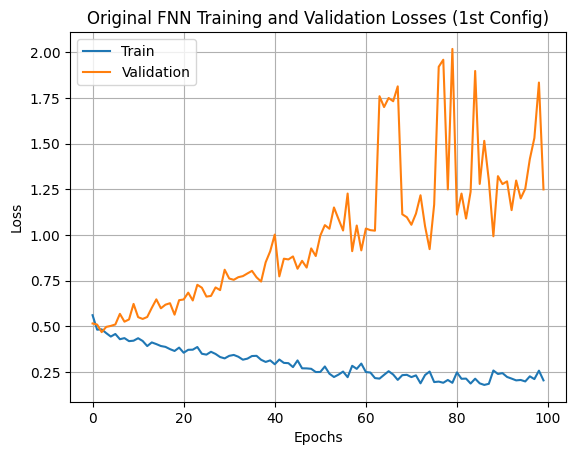

In [121]:
plot_curve(history[0][0],history[0][1],"Loss","Original FNN Training and Validation Losses (1st Config)")

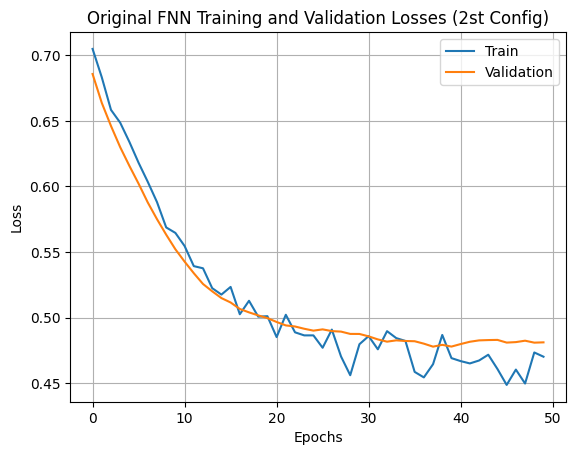

In [122]:
plot_curve(history[1][0],history[1][1],"Loss","Original FNN Training and Validation Losses (2st Config)")

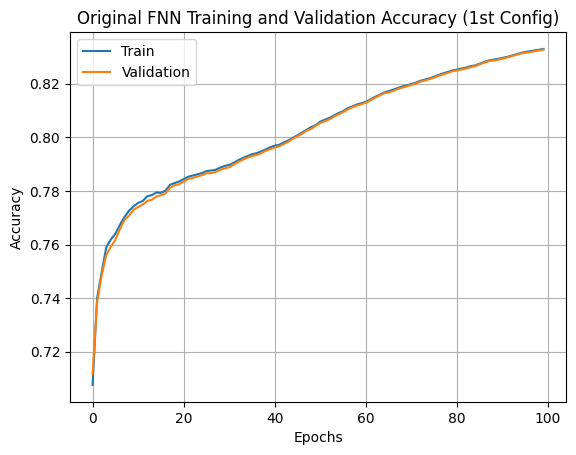

In [123]:
plot_curve(history[0][2],history[0][3],"Accuracy","Original FNN Training and Validation Accuracy (1st Config)")

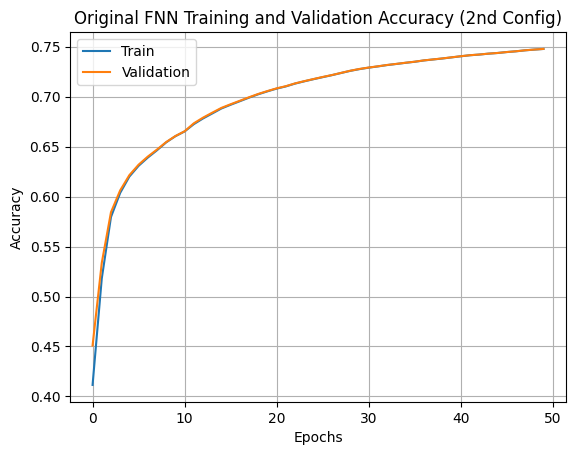

In [124]:
plot_curve(history[1][2],history[1][3],"Accuracy","Original FNN Training and Validation Accuracy (2nd Config)")

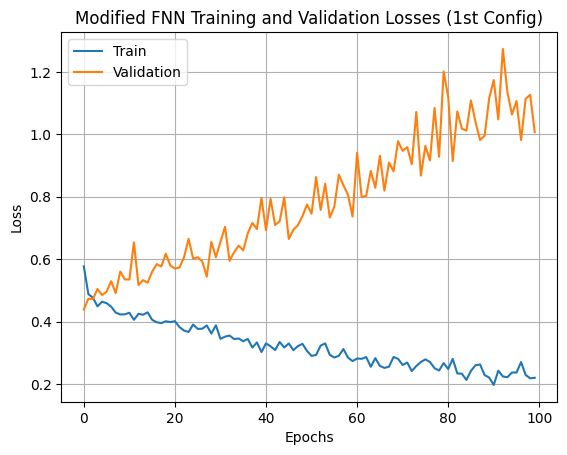

In [125]:
plot_curve(history_mod[0][0],history_mod[0][1],"Loss","Modified FNN Training and Validation Losses (1st Config)")

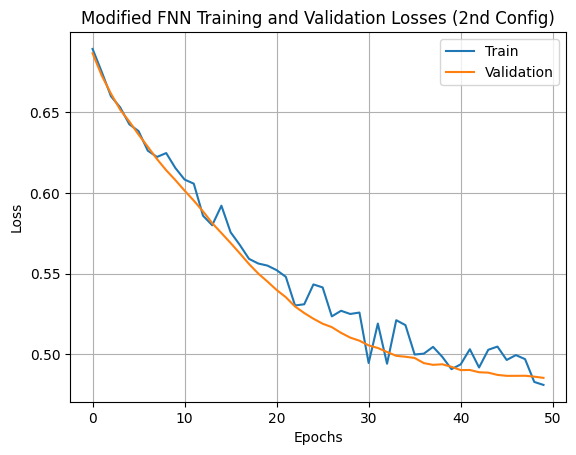

In [126]:
plot_curve(history_mod[1][0],history_mod[1][1],"Loss","Modified FNN Training and Validation Losses (2nd Config)")

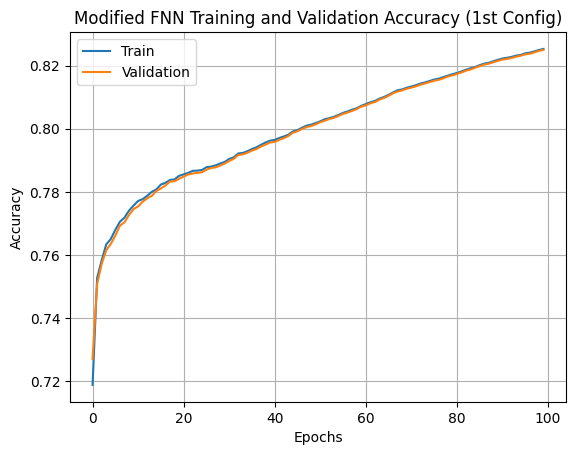

In [127]:
plot_curve(history_mod[0][2],history_mod[0][3],"Accuracy","Modified FNN Training and Validation Accuracy (1st Config)")

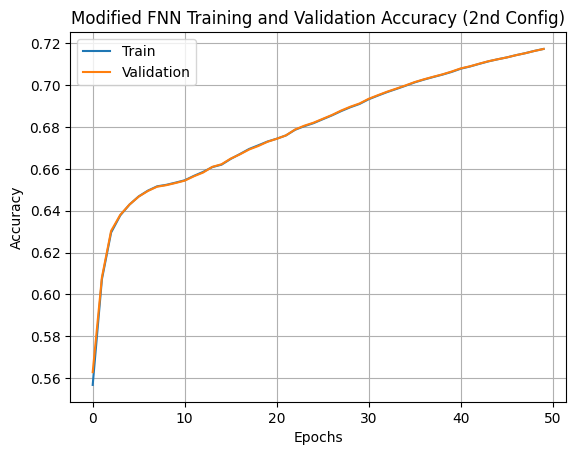

In [128]:
plot_curve(history_mod[1][2],history_mod[1][3],"Accuracy","Modified FNN Training and Validation Accuracy (2nd Config)")

### Here we can see that the second configuration is working best for both the neural networks. Mainly it is due to the SGD optimizer over Adam as well as the difference in learning rates. Also the modified model is working better as the layer provided first was too deep and can cause overfitting.

## **2. Guessing the kernel of the convolution**

In [135]:
X = torch.load("x.pt")
y = torch.load("y.pt")

/tmp/ipykernel_15352/2209021543.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  X = torch.load("x.pt")
/tmp/ipykernel_15352/2209021543.py:2: FutureWarning: You are using

In [146]:
X

tensor([[[[0.9216, 0.4824, 0.8980,  ..., 0.2902, 0.6078, 0.3294],
          [0.7725, 0.0392, 0.7529,  ..., 0.1843, 0.1922, 0.2706],
          [0.6078, 0.0353, 0.9412,  ..., 0.6667, 0.6706, 0.4196],
          ...,
          [0.7569, 0.0118, 0.3412,  ..., 0.2784, 0.1843, 0.3529],
          [0.0902, 0.7373, 0.7451,  ..., 0.1569, 0.3490, 0.3059],
          [0.1765, 0.3255, 0.6157,  ..., 0.7686, 0.2392, 0.0549]]],


        [[[0.9882, 0.5373, 0.0824,  ..., 0.3216, 0.2745, 0.2980],
          [0.6431, 0.5765, 0.5647,  ..., 0.7412, 0.3569, 0.7922],
          [0.4745, 0.9216, 0.8824,  ..., 0.8078, 0.9412, 0.8078],
          ...,
          [0.4353, 0.8196, 0.6784,  ..., 0.5804, 0.7373, 0.7451],
          [0.1333, 0.2627, 0.6235,  ..., 0.8235, 0.5412, 0.0275],
          [0.8000, 0.0275, 0.9647,  ..., 0.4824, 0.3922, 0.1961]]],


        [[[0.5804, 0.1176, 0.8235,  ..., 0.2471, 0.5137, 0.2000],
          [0.9333, 0.6353, 0.3765,  ..., 0.8157, 0.6824, 0.3333],
          [0.3922, 0.9216, 0.3333,  ..

In [136]:
dataset = TensorDataset(X,y)

train_size = int(0.7*len(dataset))
indices = torch.randperm(len(X)).tolist()

train_ds = Subset(dataset, indices[:train_size])
test_ds = Subset(dataset, indices[train_size:])

In [137]:
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64)

In [138]:
X.shape

torch.Size([7680, 1, 28, 28])

In [139]:
y.shape

torch.Size([7680, 1, 26, 26])

In [140]:
print("Before Convolution: ")
print(X[0])
print()
print("After Convolution: ")
print(y[0])

Before Convolution: 
tensor([[[0.9216, 0.4824, 0.8980, 0.9098, 0.6745, 0.7765, 0.9647, 0.4039,
          0.2549, 0.6431, 0.6118, 0.6078, 0.2784, 0.4471, 0.2353, 0.7608,
          0.6353, 0.8471, 0.5098, 0.4392, 0.2471, 0.0706, 0.8000, 0.6745,
          0.2745, 0.2902, 0.6078, 0.3294],
         [0.7725, 0.0392, 0.7529, 0.8588, 0.6235, 0.1333, 0.7843, 0.7098,
          0.3176, 0.5804, 0.3020, 0.2314, 0.4510, 0.9922, 0.1255, 0.4039,
          0.7373, 0.1137, 0.7765, 0.5176, 0.0902, 0.3490, 0.0745, 0.5255,
          0.5176, 0.1843, 0.1922, 0.2706],
         [0.6078, 0.0353, 0.9412, 0.6745, 0.9098, 0.8392, 0.8235, 0.3765,
          0.4392, 0.8549, 0.2078, 0.5216, 0.3451, 0.8078, 0.9569, 0.2706,
          0.8353, 0.5216, 0.0549, 0.4235, 0.5725, 0.3647, 0.8078, 0.2549,
          0.0078, 0.6667, 0.6706, 0.4196],
         [0.5333, 0.5216, 0.1373, 0.0510, 0.7412, 0.5255, 0.9608, 0.6000,
          0.2863, 0.1765, 0.3294, 0.4824, 0.5059, 0.4863, 0.7843, 0.0275,
          0.6392, 0.5804, 0.0627, 0.

In [148]:
y.shape

torch.Size([26, 26])

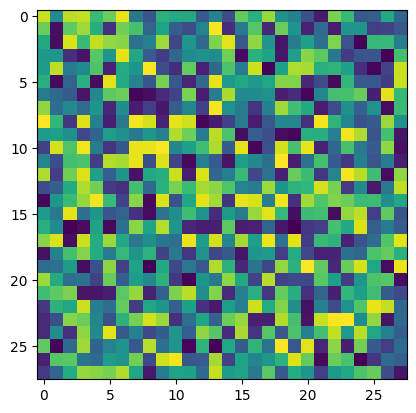

In [156]:
plt.imshow(X[0].reshape(28,28,1))

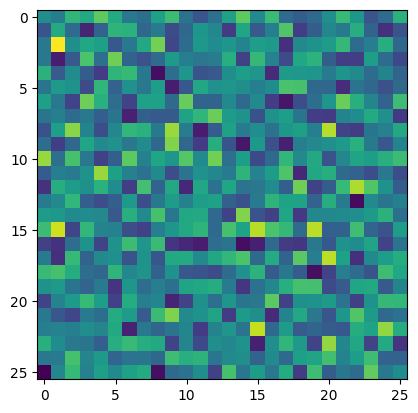

In [157]:
plt.imshow(y[0].reshape(26,26,1))

In [167]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 == nn.Sequential(nn.Conv2d(1, 32, 3), nn.ReLU())
        self.fc1 = nn.Sequential(nn.Linear(32*3*3,128), n.ReLU())
        self.fc2 = nn.Linear(128, 1)
    def forward(self,x):
        x = self.conv1
        x = torch.flatten(x,1)
        return self.fc2(self.fc1(x))

In [168]:
def evaluate(model: nn.Module, loader: DataLoader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            outputs = model(x)
            _, preds = torch.max(outputs, 1)

            correct += (preds == y).sum().item()
            total += y.size(0)
    return 100 * correct / total


def train_model(model: nn.Module, epochs=4):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    accuracy_history = []
    for epoch in range(epochs):
        model.train()
        for x, y in train_loader:
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
        acc = evaluate(model, test_loader)
        accuracy_history.append(acc)
        print(f"Epoch {epoch+1}/{epochs} | Test Accuracy: {acc:.2f}%")
    return (accuracy_history, accuracy_history[-1])

def plot_accuracy(name, history):
    plt.figure()
    plt.plot(history, label=name)
    plt.xlabel("Epoch")
    plt.ylabel("Test Accuracy (%)")
    plt.title("Model Accuracy Comparison")
    plt.legend()
    plt.show()

In [ ]:
print("Training CNN")
model = CNN()
hist, acc = train_model(model)

In [ ]:
plot_accuracy("CNN",hist)

## **3. Univariate Time Series Forecasting**

In [160]:
train_dataset = pd.read_csv("DailyDelhiClimateTrain.csv")
test_dataset = pd.read_csv("DailyDelhiClimateTest.csv")

In [161]:
train_dataset

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000
...,...,...,...,...,...
1457,2016-12-28,17.217391,68.043478,3.547826,1015.565217
1458,2016-12-29,15.238095,87.857143,6.000000,1016.904762
1459,2016-12-30,14.095238,89.666667,6.266667,1017.904762
1460,2016-12-31,15.052632,87.000000,7.325000,1016.100000


In [162]:
def train_and_evaluate(model,train_loader, criterion, optimizer, epochs = 5):
    model.train()
    loss_history = []

    for epoch in range(epochs):
        total_loss = 0
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs=model(inputs)
            if outputs.shape!=targets.shape and len(targets.shape)==1:
                outputs = outputs.squeeze()
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            total_loss+=loss.item()
        avg_loss=total_loss/len(train_loader)
        loss_history.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
    return loss_history

In [163]:
def plot_losses(losses_dict, title):
    plt.figure(figsize=(10,6))
    for model_name, losses in losses_dict.items():
        plt.plot(losses, label=model_name, marker='o')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

In [164]:
class NextWordModel(nn.Module):
    def __init__(self, rnn_type, window_size, embed_dim, hidden_dim=64):
        super(NextWordModel, self).__init__()
        self.embedding = nn.Embedding(window_size, embed_dim)
        if rnn_type == 'RNN':
            self.rnn =  nn.RNN(embed_dim, hidden_dim, batch_first = True)
        if rnn_type == 'LSTM':
            self.rnn =  nn.LSTM(embed_dim, hidden_dim, batch_first = True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self,x):
        embedded = self.embedding(x)
        output, hidden = self.rnn(embedded)

        if isinstance(hidden, tuple):
            hidden = hidden[0]

        final_hidden = hidden[-1]
        return self.fc(final_hidden)

In [ ]:
embed_dim = 5